**Step 1: Install & Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


**Step 2: Download & Load the Dataset**

In [2]:
import urllib.request
import zipfile
import os

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip'
urllib.request.urlretrieve(url, 'bank-additional.zip')

with zipfile.ZipFile('bank-additional.zip', 'r') as z:
    z.extractall('.')

print('Files extracted:')
for f in os.listdir('bank-additional'):
    print(' ', f)

Files extracted:
  .Rhistory
  bank-additional.csv
  bank-additional-names.txt
  .DS_Store
  bank-additional-full.csv


In [3]:
df = pd.read_csv('bank-additional/bank-additional-full.csv', sep=';')

print('Shape:', df.shape)
df.head()

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


**Step 3: Exploratory Data Analysis (EDA)**

In [4]:
print('=== Dataset Info ===')
df.info()

print('\n=== Statistical Summary ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [5]:
print('=== Missing values ===')
print(df.isnull().sum())

print('\n=== Columns with unknown values ===')
for col in df.select_dtypes(include='object').columns:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        print(f'  {col}: {n} unknowns ({n/len(df)*100:.1f}%)')

=== Missing values ===
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

=== Columns with unknown values ===
  job: 330 unknowns (0.8%)
  marital: 80 unknowns (0.2%)
  education: 1731 unknowns (4.2%)
  default: 8597 unknowns (20.9%)
  housing: 990 unknowns (2.4%)
  loan: 990 unknowns (2.4%)


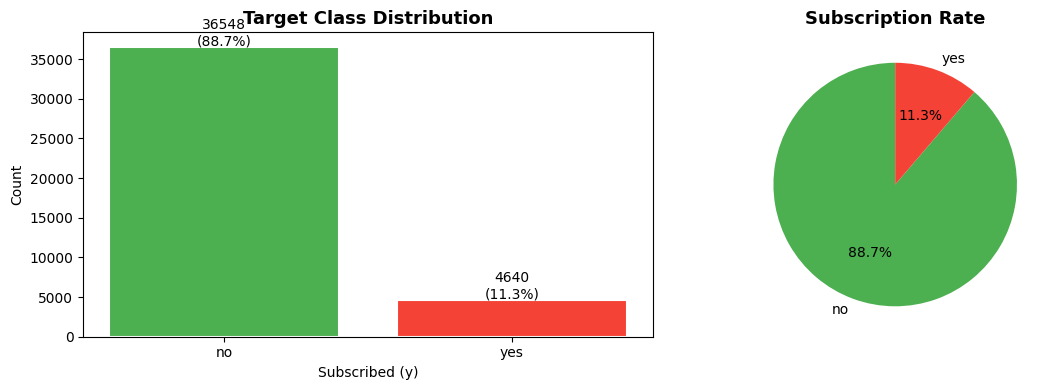

Class imbalance detected — will use F1-score for evaluation!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['y'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Subscribed (y)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90)
axes[1].set_title('Subscription Rate', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print('Class imbalance detected — will use F1-score for evaluation!')

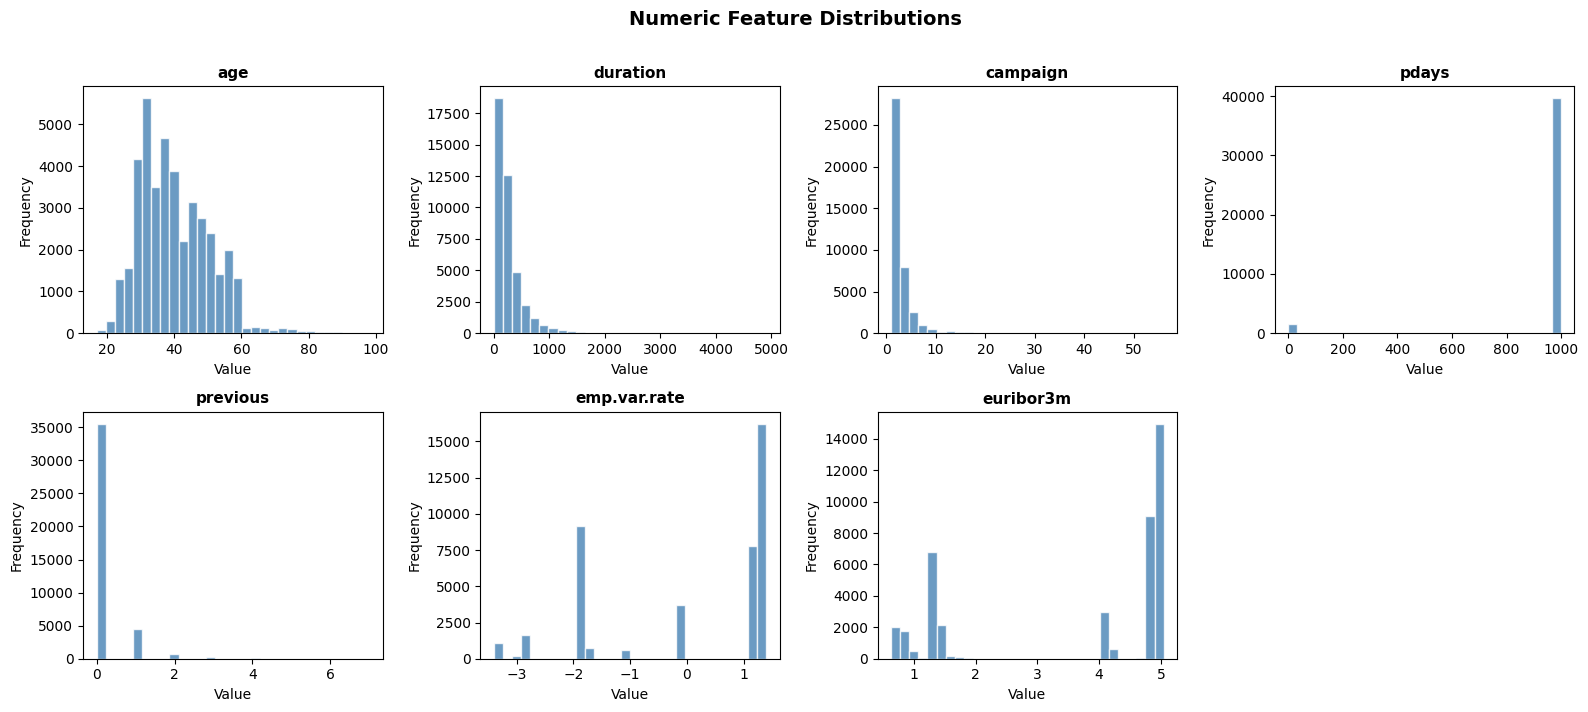

In [7]:
num_cols = ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'euribor3m']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

axes[-1].axis('off')  # hide last empty subplot
plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Step 4: Data Preprocessing**

In [8]:
data = df.copy()

cat_cols = data.select_dtypes(include='object').columns.tolist()
cat_cols.remove('y')

for col in cat_cols:
    data[col] = data[col].replace('unknown', np.nan)
    data[col] = data[col].fillna(data[col].mode()[0])

print('Unknown values handled.')

le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

data['y'] = le.fit_transform(data['y'])

print('Categorical encoding done.')
print('\nFirst 5 rows after preprocessing:')
data.head()

Unknown values handled.
Categorical encoding done.

First 5 rows after preprocessing:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,1,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,1,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


In [9]:
X = data.drop('y', axis=1)
y = data['y']

print('Features shape:', X.shape)
print('Target shape  :', y.shape)
print('Feature columns:', list(X.columns))

Features shape: (41188, 20)
Target shape  : (41188,)
Feature columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


 Step 5: Train / Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')
print(f'Train class balance: {y_train.value_counts().to_dict()}')
print(f'Test  class balance: {y_test.value_counts().to_dict()}')

Training set : 32950 samples
Test set     : 8238 samples
Train class balance: {0: 29238, 1: 3712}
Test  class balance: {0: 7310, 1: 928}


**Step 6: Build & Train the Decision Tree**

In [11]:
clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

clf.fit(X_train, y_train)
print('Model trained successfully!')
print(f'Tree depth     : {clf.get_depth()}')
print(f'Number of leaves: {clf.get_n_leaves()}')

Model trained successfully!
Tree depth     : 5
Number of leaves: 32


**Step 7: Evaluate the Model**

In [12]:
y_pred = clf.predict(X_test)


acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc*100:.2f}%\n')

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['No (0)', 'Yes (1)']))

Accuracy: 91.81%

=== Classification Report ===
              precision    recall  f1-score   support

      No (0)       0.94      0.97      0.95      7310
     Yes (1)       0.68      0.52      0.59       928

    accuracy                           0.92      8238
   macro avg       0.81      0.74      0.77      8238
weighted avg       0.91      0.92      0.91      8238



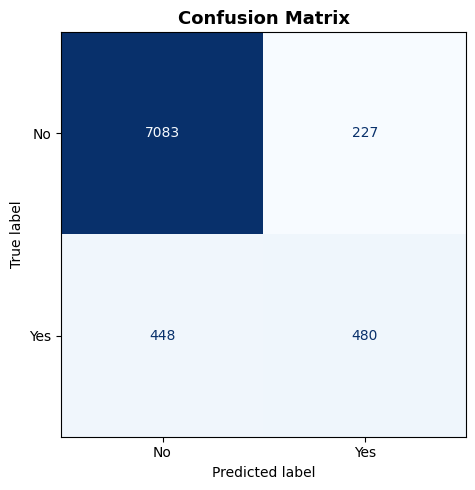

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print(f'Train Accuracy : {train_acc*100:.2f}%')
print(f'Test  Accuracy : {test_acc*100:.2f}%')

if train_acc - test_acc > 0.05:
    print('\nWarning: Possible overfitting! Consider reducing max_depth.')
else:
    print('\nModel is well-generalised (no major overfitting).')

Train Accuracy : 91.62%
Test  Accuracy : 91.81%

Model is well-generalised (no major overfitting).


**Step 8: Visualize the Decision Tree**

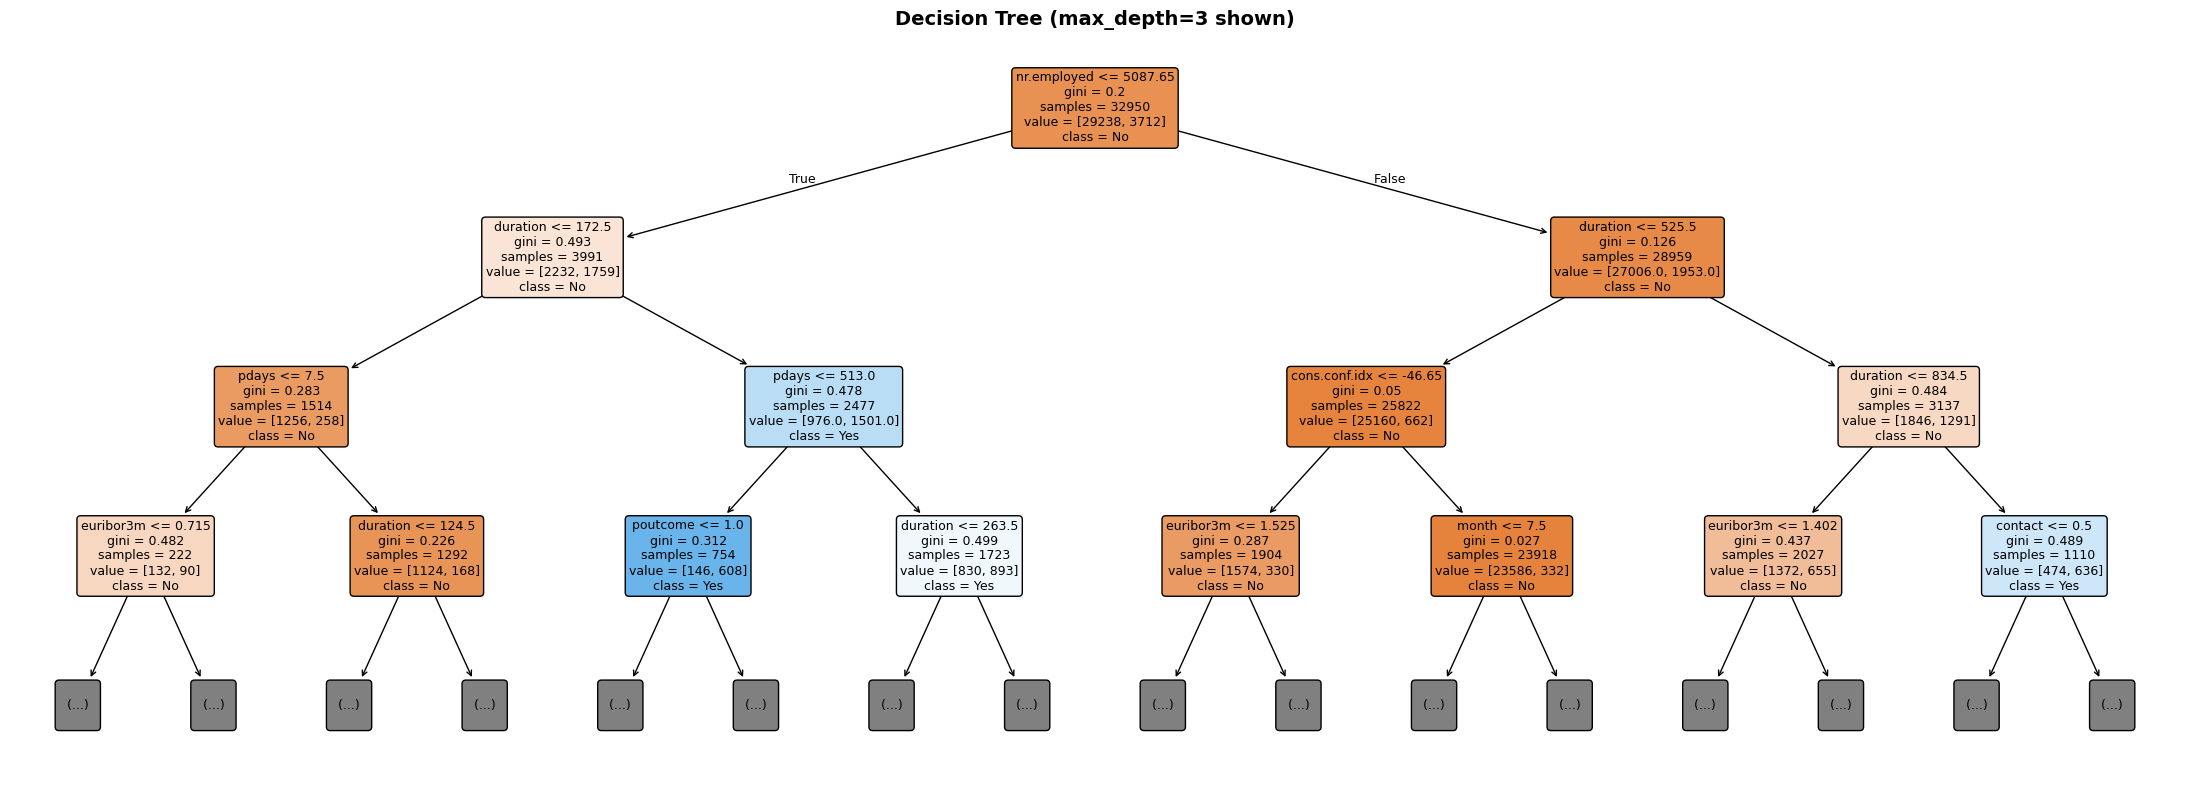

In [15]:
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    clf,
    max_depth=3,
    feature_names=X.columns.tolist(),
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title('Decision Tree (max_depth=3 shown)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

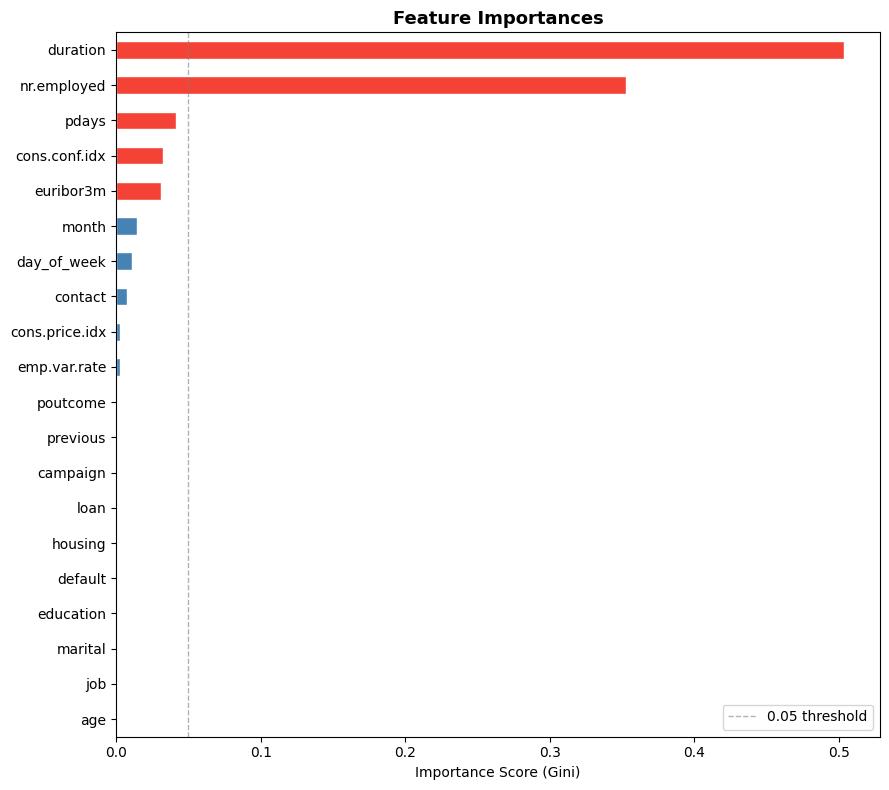


Top 5 Most Important Features:
duration         0.503155
nr.employed      0.352524
pdays            0.041754
cons.conf.idx    0.032333
euribor3m        0.030821


In [16]:

importances = pd.Series(clf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
colors = ['#F44336' if imp > importances.quantile(0.75) else 'steelblue' for imp in importances]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score (Gini)')
ax.axvline(x=0.05, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='0.05 threshold')
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop 5 Most Important Features:')
print(importances.sort_values(ascending=False).head(5).to_string())

**Step 9: Hyperparameter Tuning with GridSearchCv**

In [17]:
param_grid = {
    'criterion'        : ['gini', 'entropy'],
    'max_depth'        : [3, 5, 7, 10, None],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf' : [5, 10, 20]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print('\nBest Parameters:', grid_search.best_params_)
print('Best CV F1 Score:', round(grid_search.best_score_, 4))

Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 10}
Best CV F1 Score: 0.5859


In [18]:
best_clf = grid_search.best_estimator_
y_pred_tuned = best_clf.predict(X_test)

print('=== Tuned Model — Classification Report ===')
print(classification_report(y_test, y_pred_tuned, target_names=['No (0)', 'Yes (1)']))

print(f'Tuned Accuracy : {accuracy_score(y_test, y_pred_tuned)*100:.2f}%')

=== Tuned Model — Classification Report ===
              precision    recall  f1-score   support

      No (0)       0.95      0.95      0.95      7310
     Yes (1)       0.62      0.61      0.61       928

    accuracy                           0.91      8238
   macro avg       0.78      0.78      0.78      8238
weighted avg       0.91      0.91      0.91      8238

Tuned Accuracy : 91.30%


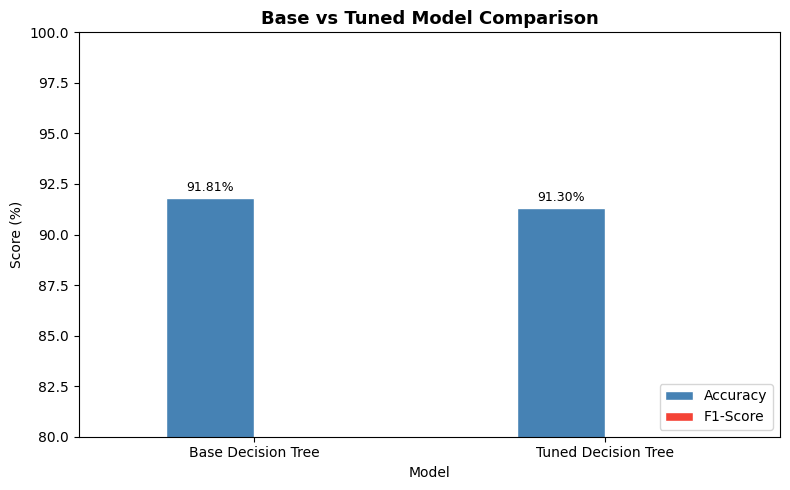

In [19]:
from sklearn.metrics import f1_score

metrics = {
    'Model'   : ['Base Decision Tree', 'Tuned Decision Tree'],
    'Accuracy': [accuracy_score(y_test, y_pred)*100,
                 accuracy_score(y_test, y_pred_tuned)*100],
    'F1-Score': [f1_score(y_test, y_pred)*100,
                 f1_score(y_test, y_pred_tuned)*100]
}

metrics_df = pd.DataFrame(metrics).set_index('Model')

ax = metrics_df.plot(kind='bar', figsize=(8, 5), color=['steelblue', '#F44336'],
                     edgecolor='white', rot=0)
ax.set_title('Base vs Tuned Model Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('Score (%)')
ax.set_ylim(80, 100)
ax.legend(loc='lower right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

Step 10: Conclusions & Insights

In [20]:
print('=' * 55)
print('         TASK 03 — FINAL SUMMARY')
print('=' * 55)

print(f'''
Dataset      : Bank Marketing (UCI)
Samples      : {len(df):,} rows | {df.shape[1]} features
Target       : y — term deposit subscription (yes/no)

Base Model Accuracy  : {accuracy_score(y_test, y_pred)*100:.2f}%
Tuned Model Accuracy : {accuracy_score(y_test, y_pred_tuned)*100:.2f}%

Top Predictive Features:
{importances.sort_values(ascending=False).head(5).to_string()}

Key Business Insight:
  Customers with longer call duration and contacted
  fewer times during the campaign are more likely
  to subscribe to a term deposit.
''')
print('=' * 55)

         TASK 03 — FINAL SUMMARY

Dataset      : Bank Marketing (UCI)
Samples      : 41,188 rows | 21 features
Target       : y — term deposit subscription (yes/no)

Base Model Accuracy  : 91.81%
Tuned Model Accuracy : 91.30%

Top Predictive Features:
duration         0.503155
nr.employed      0.352524
pdays            0.041754
cons.conf.idx    0.032333
euribor3m        0.030821

Key Business Insight:
  Customers with longer call duration and contacted
  fewer times during the campaign are more likely
  to subscribe to a term deposit.

